# Three-seed checkpoint generator evaluation

## TL;DR

This report-only notebook evaluates the frozen VAE-v3 and conditional-diffusion spectrogram pools with the selected CRNN. Across three generation seeds, VAE-v3 reaches 96.67% target-label accuracy and 96.66% macro F1; diffusion reaches 92.44% and 92.42%, respectively. In the same CRNN feature space, VAE-v3 is closer to the real test distribution, while diffusion's diversity ratio is nearer 1. These diagnostics do not identify a perceptual-quality winner.

## Context and methods

The VAE checkpoint was **not retrained**. Its existing posterior bank was filtered to 256 Northern Cardinal, 247 Song Sparrow, and 256 American Robin anchors, then sampled with `z = mu + 0.35 * std * epsilon`. The VAE pools were refreshed by inference. The existing diffusion pools were reused exactly as recorded; **no diffusion spectrograms were regenerated**.

The notebook reads only the bounded schema-v3 package under `reports/generator_checkpoint_evaluation_2026-08-12/`. Copy-risk calibration uses the 510-row generator-safe validation subset; the held-out 489-row test set is unchanged. The selected CRNN is the sole evaluator. Run top-to-bottom to reproduce all displayed tables and checks.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'src' / 'bird_song').is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
REPORT_DIR = PROJECT_ROOT / 'reports' / 'generator_checkpoint_evaluation_2026-08-12'
assert REPORT_DIR.is_dir(), REPORT_DIR

summary = json.loads((REPORT_DIR / 'summary.json').read_text(encoding='utf-8'))
protocol = json.loads((REPORT_DIR / 'protocol.json').read_text(encoding='utf-8'))
provenance = json.loads((REPORT_DIR / 'provenance.json').read_text(encoding='utf-8'))

schema_versions = {summary['schema_version'], protocol['schema_version'], provenance['schema_version']}
assert schema_versions == {3}, schema_versions
assert summary['classifier'] == protocol['classifier'] == 'crnn'
evaluator_names = [item['classifier'] for item in provenance['evaluators']]
assert evaluator_names == ['crnn'], evaluator_names

vae_contract = protocol['generation_contracts']['vae_v3']
diffusion_contract = protocol['generation_contracts']['diffusion']
assert vae_contract['posterior_bank_counts'] == {
    'Northern Cardinal': 256, 'Song Sparrow': 247, 'American Robin': 256,
}
assert vae_contract['posterior_bank_derivation'] == 'filtered_existing_posterior_bank'
assert vae_contract['vae_checkpoint_retrained'] is False
assert vae_contract['temperature'] == 0.35
assert vae_contract['reparameterization'] == (
    'mu + temperature * exp(0.5 * logvar) * epsilon'
)
assert vae_contract['pool_reused_after_vae_bank_filter'] is False
assert vae_contract['spectrograms_regenerated_after_vae_bank_filter'] is True
assert diffusion_contract['pool_reused_after_vae_bank_filter'] is True
assert diffusion_contract['spectrograms_regenerated_after_vae_bank_filter'] is False

validation_contract = protocol['validation_protocol']
assert validation_contract['validation_counts']['before']['rows'] == 519
assert validation_contract['validation_counts']['after']['rows'] == 510
assert validation_contract['test_unchanged']['rows'] == 489
assert validation_contract['test_unchanged']['excluded_rows'] == 0

vae_provenance = provenance['checkpoints']['vae_v3']
diffusion_provenance = provenance['checkpoints']['diffusion']
assert vae_provenance['checkpoint_retrained_for_refresh'] is False
assert vae_provenance['posterior_bank_counts'] == vae_contract['posterior_bank_counts']
assert diffusion_provenance['pool_reused_after_vae_bank_filter'] is True
assert diffusion_provenance['spectrograms_regenerated_after_vae_bank_filter'] is False
assert provenance['validation_protocol']['validation_rows'] == 510
assert provenance['validation_protocol']['test_rows_unchanged'] == 489

print(summary['title'])
print('Report schema:', summary['schema_version'])
print('Generated arrays:', summary['generated_arrays_total'])
print('Seeds:', protocol['seeds'])
print('Evaluator:', protocol['classifier'])
print('VAE bank anchors:', vae_contract['posterior_bank_counts'])
print('Validation rows:', validation_contract['validation_counts']['after']['rows'])
print('Test rows (unchanged):', validation_contract['test_unchanged']['rows'])
print('Diffusion pools reused; regenerated:', diffusion_contract['spectrograms_regenerated_after_vae_bank_filter'])

Three-seed checkpoint generator evaluation
Report schema: 3
Generated arrays: 3600
Seeds: [42, 123, 777]
Evaluator: crnn
VAE bank anchors: {'Northern Cardinal': 256, 'Song Sparrow': 247, 'American Robin': 256}
Validation rows: 510
Test rows (unchanged): 489
Diffusion pools reused; regenerated: False


In [2]:
calibration = pd.DataFrame(summary['calibration'])
required_calibration_columns = {
    'classifier', 'split', 'sample_count', 'accuracy', 'macro_f1', 'macro_recall',
    'mean_confidence', 'mean_entropy', 'expected_accuracy', 'expected_macro_f1',
}
missing_calibration_columns = required_calibration_columns - set(calibration.columns)
assert not missing_calibration_columns, missing_calibration_columns
assert set(calibration['classifier']) == {'crnn'}
assert (calibration['accuracy'] - calibration['expected_accuracy']).abs().max() < 1e-8
assert (calibration['macro_f1'] - calibration['expected_macro_f1']).abs().max() < 1e-8
display(calibration[[
    'classifier', 'split', 'sample_count', 'accuracy', 'macro_f1', 'macro_recall',
    'mean_confidence', 'mean_entropy',
]].round(4))

display(pd.DataFrame({
    'setting': [
        'schema version', 'samples/species/seed', 'total arrays/model',
        'resamples', 'resample size/species', 'copy-risk threshold quantile',
        'generator-safe validation rows', 'unchanged held-out test rows',
        'VAE checkpoint retrained', 'VAE pool refreshed',
        'diffusion pool reused', 'diffusion spectrograms regenerated',
    ],
    'value': [
        protocol['schema_version'], protocol['samples_per_species'],
        protocol['total_samples_per_model'], protocol['sample_sensitive_metrics']['resamples'],
        protocol['sample_sensitive_metrics']['sample_size_per_species'],
        protocol['copy_risk']['quantile'],
        validation_contract['validation_counts']['after']['rows'],
        validation_contract['test_unchanged']['rows'],
        vae_contract['vae_checkpoint_retrained'],
        vae_contract['spectrograms_regenerated_after_vae_bank_filter'],
        diffusion_contract['pool_reused_after_vae_bank_filter'],
        diffusion_contract['spectrograms_regenerated_after_vae_bank_filter'],
    ],
}))

,classifier,split,sample_count,accuracy,macro_f1,macro_recall,mean_confidence,mean_entropy
0,crnn,test,489,0.8998,0.9016,0.9018,0.9209,0.2633


,setting,value
0,schema version,3
1,samples/species/seed,200
2,total arrays/model,1800
3,resamples,200
4,resample size/species,128
5,copy-risk threshold quantile,0.05
6,generator-safe validation rows,510
7,unchanged held-out test rows,489
8,VAE checkpoint retrained,False
9,VAE pool refreshed,True


In [3]:
per_seed = pd.read_csv(REPORT_DIR / 'metrics_per_seed.csv')
aggregate = pd.read_csv(REPORT_DIR / 'metrics_aggregate.csv')
classifier_scores = pd.read_csv(REPORT_DIR / 'classifier_scores.csv')
nearest = pd.read_csv(REPORT_DIR / 'nearest_neighbor_summary.csv')

required_per_seed_columns = {
    'model', 'seed', 'classifier', 'species', 'target_label_accuracy',
    'species_recall', 'species_f1', 'macro_f1', 'frechet_mean',
    'precision_mean', 'recall_mean', 'density_mean', 'coverage_mean',
    'real_diversity_mean', 'generated_diversity_mean', 'diversity_ratio_mean',
    'exact_train_duplicate_count', 'pool_unique_count',
    'pixel_distribution_wasserstein', 'pixel_mean_delta', 'pixel_std_delta',
}
required_classifier_columns = {
    'model', 'seed', 'classifier', 'sample_count', 'accuracy',
    'macro_f1', 'macro_recall', 'mean_confidence', 'mean_entropy',
}
assert not (required_per_seed_columns - set(per_seed.columns))
assert not (required_classifier_columns - set(classifier_scores.columns))
required_nearest_columns = {
    'model', 'seed', 'classifier', 'species', 'validation_threshold_quantile',
    'copy_risk_threshold', 'generated_count', 'nearest_train_min',
    'nearest_train_median', 'below_threshold_count',
    'below_threshold_fraction', 'exact_train_duplicate_count',
}
assert not (required_nearest_columns - set(nearest.columns))

for frame_name, frame in {
    'metrics_per_seed': per_seed,
    'metrics_aggregate': aggregate,
    'classifier_scores': classifier_scores,
    'nearest_neighbor_summary': nearest,
}.items():
    assert set(frame['classifier']) == {'crnn'}, frame_name

models = set(protocol['models'])
seeds = set(protocol['seeds'])
species = set(protocol['class_order_generator'])
assert set(per_seed['model']) == models
assert set(per_seed['seed']) == seeds
assert set(per_seed['species']) == species
assert len(per_seed) == len(models) * len(seeds) * len(species)
assert len(aggregate) == len(models) * len(species)
assert len(classifier_scores) == len(models) * len(seeds)
assert len(nearest) == len(models) * len(seeds) * len(species)

expected_generated_arrays = (
    len(models) * len(seeds) * len(species) * protocol['samples_per_species']
)
assert summary['generated_arrays_total'] == expected_generated_arrays == 3600
assert (classifier_scores['sample_count'] == 600).all()
assert (per_seed['pool_unique_count'] == 600).all()
assert (nearest['generated_count'] == 200).all()
assert (nearest['validation_threshold_quantile'] == protocol['copy_risk']['quantile']).all()
assert (per_seed['exact_train_duplicate_count'] == 0).all()

seed_target_accuracy = (
    per_seed.groupby(['model', 'seed'], as_index=False)
    .agg(target_label_accuracy=('target_label_accuracy', 'mean'))
)
seed_results = classifier_scores.merge(seed_target_accuracy, on=['model', 'seed'], validate='one_to_one')
assert (seed_results['accuracy'] - seed_results['target_label_accuracy']).abs().max() < 1e-12
display(seed_results[[
    'model', 'seed', 'target_label_accuracy', 'macro_f1', 'macro_recall',
    'mean_confidence', 'mean_entropy',
]].sort_values(['model', 'seed']).round(4))

,model,seed,target_label_accuracy,macro_f1,macro_recall,mean_confidence,mean_entropy
3,diffusion,42,0.9150,0.9148,0.9150,0.9238,0.2455
4,diffusion,123,0.9267,0.9264,0.9267,0.9285,0.2339
5,diffusion,777,0.9317,0.9313,0.9317,0.9396,0.2134
0,vae_v3,42,0.9633,0.9631,0.9633,0.9408,0.2160
1,vae_v3,123,0.9567,0.9566,0.9567,0.9377,0.2203
2,vae_v3,777,0.9800,0.9800,0.9800,0.9436,0.2140


,model,species,target_label_accuracy_mean,species_recall_mean,species_f1_mean,macro_f1_mean,frechet_mean_mean,precision_mean_mean,recall_mean_mean,density_mean_mean,coverage_mean_mean,real_diversity_mean_mean,generated_diversity_mean_mean,diversity_ratio_mean_mean
0,diffusion,American Robin,0.9400,0.9400,0.9353,0.9242,29.7063,0.4914,0.8197,0.2566,0.4854,9.7304,10.2914,1.0580
1,diffusion,Northern Cardinal,0.8433,0.8433,0.9133,0.9242,39.6555,0.8181,0.8522,0.5138,0.6370,14.7044,14.8639,1.0111
2,diffusion,Song Sparrow,0.9900,0.9900,0.9239,0.9242,54.4031,0.3865,0.7901,0.1636,0.3312,11.2574,10.7501,0.9557
3,vae_v3,American Robin,0.9967,0.9967,0.9701,0.9666,13.8034,0.7527,0.8701,0.4752,0.6661,9.7304,8.4274,0.8664
4,vae_v3,Northern Cardinal,0.9667,0.9667,0.9748,0.9666,42.9346,0.9062,0.9062,0.7037,0.7172,14.7044,11.5432,0.7852
5,vae_v3,Song Sparrow,0.9367,0.9367,0.9549,0.9666,11.9471,0.8994,0.9154,0.7480,0.8425,11.2574,10.8438,0.9640


,model,target_label_accuracy,target_label_accuracy_sd,macro_f1,macro_f1_sd,frechet_mean_mean,precision_mean_mean,recall_mean_mean,density_mean_mean,coverage_mean_mean,diversity_ratio_mean_mean,pixel_distribution_wasserstein_mean
0,diffusion,0.9244,0.0086,0.9242,0.0084,41.255,0.5654,0.8207,0.3114,0.4845,1.0083,0.1916
1,vae_v3,0.9667,0.0120,0.9666,0.0121,22.895,0.8528,0.8972,0.6423,0.7419,0.8719,0.0787


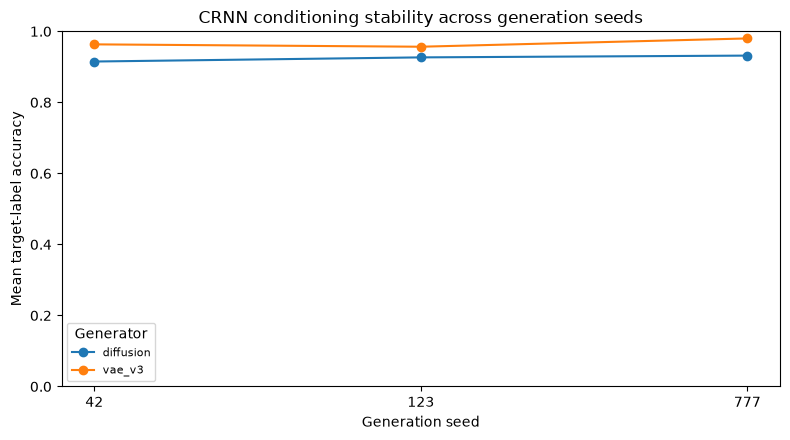

In [4]:
quality_columns = [
    'model', 'species', 'target_label_accuracy_mean', 'species_recall_mean',
    'species_f1_mean', 'macro_f1_mean', 'frechet_mean_mean',
    'precision_mean_mean', 'recall_mean_mean', 'density_mean_mean',
    'coverage_mean_mean', 'real_diversity_mean_mean',
    'generated_diversity_mean_mean', 'diversity_ratio_mean_mean',
]
missing_quality_columns = set(quality_columns) - set(aggregate.columns)
assert not missing_quality_columns, missing_quality_columns
display(aggregate[quality_columns].sort_values(['model', 'species']).round(4))

model_summary = (
    classifier_scores.groupby('model', as_index=False)
    .agg(
        target_label_accuracy=('accuracy', 'mean'),
        target_label_accuracy_sd=('accuracy', 'std'),
        macro_f1=('macro_f1', 'mean'),
        macro_f1_sd=('macro_f1', 'std'),
    )
)
feature_summary = (
    aggregate.groupby('model', as_index=False)[[
        'frechet_mean_mean', 'precision_mean_mean', 'recall_mean_mean',
        'density_mean_mean', 'coverage_mean_mean', 'diversity_ratio_mean_mean',
        'pixel_distribution_wasserstein_mean',
    ]].mean()
)
display(model_summary.merge(feature_summary, on='model', validate='one_to_one').round(4))

figure, axis = plt.subplots(figsize=(8, 4.5))
for model, group in per_seed.groupby('model'):
    values = group.groupby('seed')['target_label_accuracy'].mean().sort_index()
    axis.plot(values.index.astype(str), values.values, marker='o', label=model)
axis.set(
    xlabel='Generation seed', ylabel='Mean target-label accuracy', ylim=(0, 1),
    title='CRNN conditioning stability across generation seeds',
)
axis.legend(title='Generator', fontsize=8)
figure.tight_layout()
display(figure)
plt.close(figure)

,model,seed,species,copy_risk_threshold,nearest_train_min,nearest_train_median,below_threshold_count,below_threshold_fraction,exact_train_duplicate_count
9,diffusion,42,American Robin,2.0642,2.1901,4.0917,0,0.000,0
10,diffusion,42,Northern Cardinal,2.6661,2.0838,4.3981,9,0.045,0
11,diffusion,42,Song Sparrow,2.5045,2.2079,4.2969,3,0.015,0
12,diffusion,123,American Robin,2.0642,2.1876,3.7966,0,0.000,0
13,diffusion,123,Northern Cardinal,2.6661,1.8791,4.2257,12,0.060,0
14,diffusion,123,Song Sparrow,2.5045,1.9463,4.3182,5,0.025,0
15,diffusion,777,American Robin,2.0642,2.2414,4.1906,0,0.000,0
16,diffusion,777,Northern Cardinal,2.6661,1.9700,4.0581,13,0.065,0
17,diffusion,777,Song Sparrow,2.5045,2.1516,4.2762,3,0.015,0
0,vae_v3,42,American Robin,2.0642,1.5150,2.7566,34,0.170,0


,model,below_threshold_count,generated_count,exact_train_duplicate_count,below_threshold_fraction
0,diffusion,45,1800,0,0.0250
1,vae_v3,660,1800,0,0.3667


,model,species,real_time_gradient_energy_mean,generated_time_gradient_energy_mean,real_frequency_gradient_energy_mean,generated_frequency_gradient_energy_mean,real_dynamic_range_mean,generated_dynamic_range_mean,real_active_bin_fraction_mean,generated_active_bin_fraction_mean,real_pixel_mean_mean,generated_pixel_mean_mean,real_pixel_std_mean,generated_pixel_std_mean,pixel_distribution_wasserstein_mean,pixel_mean_delta_mean,pixel_std_delta_mean
0,diffusion,American Robin,0.0924,0.0781,0.0699,0.0605,1.9651,1.9582,0.8636,0.7268,-0.4009,-0.3081,0.3749,0.5544,0.1912,0.0928,0.1795
1,diffusion,Northern Cardinal,0.1077,0.0842,0.0721,0.0540,1.9631,1.8399,0.9208,0.8332,-0.2650,-0.2366,0.3866,0.4903,0.1141,0.0284,0.1036
2,diffusion,Song Sparrow,0.1030,0.0704,0.0745,0.0560,1.8740,1.9566,0.9625,0.6577,-0.2250,-0.3832,0.3362,0.5677,0.2695,-0.1582,0.2316
3,vae_v3,American Robin,0.0924,0.0755,0.0699,0.0410,1.9651,1.9738,0.8636,0.9047,-0.4009,-0.3043,0.3749,0.3721,0.0974,0.0967,-0.0028
4,vae_v3,Northern Cardinal,0.1077,0.0877,0.0721,0.0426,1.9631,1.9366,0.9208,0.9547,-0.2650,-0.1841,0.3866,0.3419,0.0900,0.0809,-0.0447
5,vae_v3,Song Sparrow,0.1030,0.0779,0.0745,0.0406,1.8740,1.9418,0.9625,0.8987,-0.2250,-0.2684,0.3362,0.3781,0.0487,-0.0434,0.0419


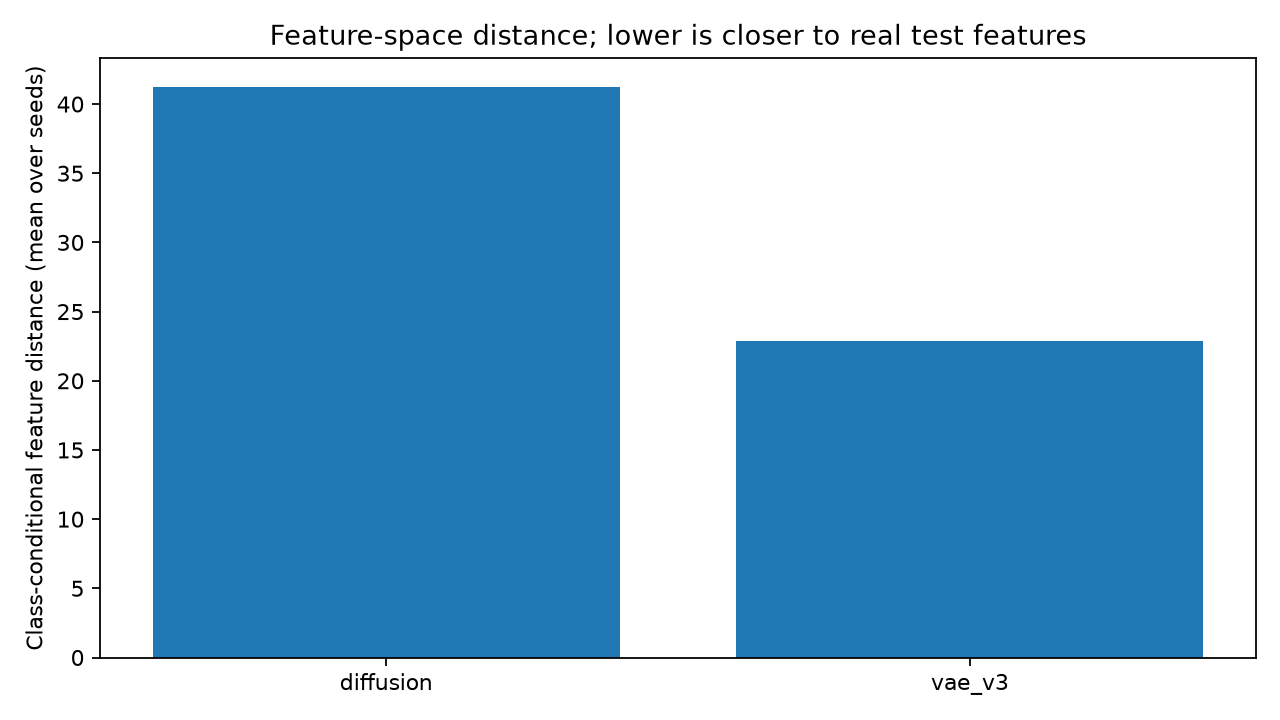

In [5]:
# Results: copy-risk and pixel diagnostics
copy_risk_columns = [
    'model', 'seed', 'species', 'copy_risk_threshold', 'nearest_train_min',
    'nearest_train_median', 'below_threshold_count',
    'below_threshold_fraction', 'exact_train_duplicate_count',
]
display(nearest[copy_risk_columns].sort_values(['model', 'seed', 'species']).round(4))

copy_risk_summary = (
    nearest.groupby('model', as_index=False)
    .agg(
        below_threshold_count=('below_threshold_count', 'sum'),
        generated_count=('generated_count', 'sum'),
        exact_train_duplicate_count=('exact_train_duplicate_count', 'max'),
    )
)
copy_risk_summary['below_threshold_fraction'] = (
    copy_risk_summary['below_threshold_count'] / copy_risk_summary['generated_count']
)
display(copy_risk_summary.round(4))

pixel_columns = [
    'model', 'species',
    'real_time_gradient_energy_mean', 'generated_time_gradient_energy_mean',
    'real_frequency_gradient_energy_mean', 'generated_frequency_gradient_energy_mean',
    'real_dynamic_range_mean', 'generated_dynamic_range_mean',
    'real_active_bin_fraction_mean', 'generated_active_bin_fraction_mean',
    'real_pixel_mean_mean', 'generated_pixel_mean_mean',
    'real_pixel_std_mean', 'generated_pixel_std_mean',
    'pixel_distribution_wasserstein_mean', 'pixel_mean_delta_mean', 'pixel_std_delta_mean',
]
missing_pixel_columns = set(pixel_columns) - set(aggregate.columns)
assert not missing_pixel_columns, missing_pixel_columns
display(aggregate[pixel_columns].sort_values(['model', 'species']).round(4))

feature_figure = REPORT_DIR / 'figures' / 'feature_distance_summary.png'
assert feature_figure.is_file(), feature_figure
display(Image(filename=str(feature_figure)))

## Takeaways

The three generation seeds are shown individually and summarized with mean and sample standard deviation; no composite score or significance test is used. The selected CRNN is the sole evaluator. Copy-risk thresholds are calibrated from 510 generator-safe validation rows before generated samples are inspected, while all 489 held-out test rows remain unchanged.

VAE-v3 records 96.67% target-label accuracy and 96.66% macro F1. Diffusion records 92.44% and 92.42%, respectively. VAE-v3 also has lower CRNN-feature Fréchet distance and stronger feature precision, recall, density, and coverage; diffusion's diversity ratio is closer to 1. The copy-risk screen flags 660/1,800 VAE arrays and 45/1,800 diffusion arrays at or below the validation-derived threshold, with zero exact training-array matches for either model.

The refresh did not retrain the VAE checkpoint: it filtered the existing posterior bank to 256/247/256 anchors and regenerated only the VAE pools with temperature 0.35. The diffusion pools were reused and no diffusion spectrogram generation was run.

These metrics cover target-label accuracy, macro F1 and recall, Fréchet distance, feature precision, recall, density and coverage, real and generated diversity, copy-risk screening, and pixel diagnostics. They support claims about frozen-CRNN compatibility and classifier-feature behavior, but not waveform quality, human realism, native generator loss, training stability, or causal augmentation benefit.